# Big Data Assighnment 

Student Name : Hetha Putane , Student Number : 23373726

- Task 3: Financial Performance Analysis

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import time
import tracemalloc
from IPython.display import display

Reading in Dataset

In [6]:
df = pd.read_csv("movies_cleaned.csv")
df.head(5)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,...,director_count,main_director,has_director,good_director_data,missing_writers,has_multiple_writers,writers_count,main_writer,has_writers,good_writers_data
0,2,Ariel,7.1,367,Released,1988-10-21,0,73,0,tt0094675,...,1,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True
1,3,Shadows in Paradise,7.3,430,Released,1986-10-17,0,74,0,tt0092149,...,1,Aki Kaurismäki,True,True,False,False,1,Aki Kaurismäki,True,True
2,5,Four Rooms,5.9,2780,Released,1995-12-09,4257354,98,4000000,tt0113101,...,4,Alexandre Rockwell,True,True,False,True,4,Allison Anders,True,True
3,6,Judgment Night,6.5,360,Released,1993-10-15,12136938,109,21000000,tt0107286,...,1,Stephen Hopkins,True,True,False,True,2,Lewis Colick,True,True
4,9,Sunday in August,6.8,28,Released,2004-09-02,0,15,0,tt0425473,...,1,Marc Meyer,True,True,False,False,1,Marc Meyer,True,True


## Task 3: Financial Performance Analysis

## <span style="color:blue">Q1: ROI per Movie</span>

In [9]:
tracemalloc.start()
start = time.perf_counter()

# ROI = (revenue - budget) / budget  (only when budget is bigger than  0)
# also btw roi is return on investment 
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")
df["budget"]  = pd.to_numeric(df["budget"], errors="coerce")

df["roi"] = np.where(
    df["budget"] > 0,
    (df["revenue"] - df["budget"]) / df["budget"],
    np.nan
)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")

df[["id", "title", "year", "revenue", "budget", "roi"]].head()

Execution Time: 0.0825 sec
Peak Memory: 26.75 MB


,id,title,year,revenue,budget,roi
0,2,Ariel,1988,0,0,NaN
1,3,Shadows in Paradise,1986,0,0,NaN
2,5,Four Rooms,1995,4257354,4000000,0.064339
3,6,Judgment Night,1993,12136938,21000000,-0.422051
4,9,Sunday in August,2004,0,0,NaN


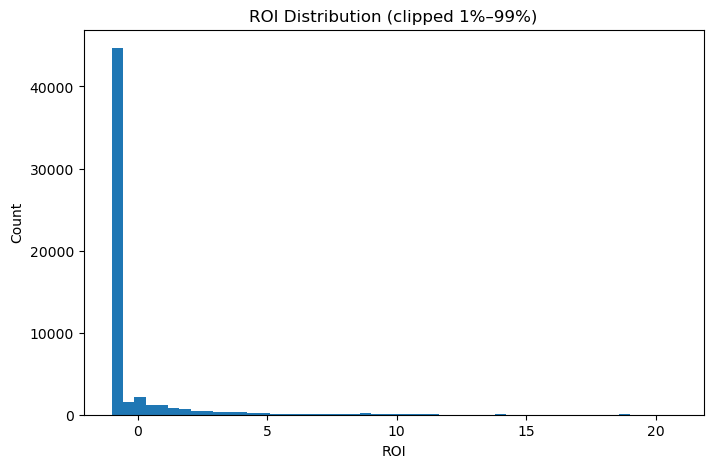

In [10]:
roi_vals = df["roi"].dropna()

roi_clip = roi_vals[roi_vals.between(roi_vals.quantile(0.01), roi_vals.quantile(0.99))]

plt.figure(figsize=(8,5))
plt.hist(roi_clip, bins=50)
plt.title("ROI Distribution (clipped 1%–99%)")
plt.xlabel("ROI")
plt.ylabel("Count")
plt.show()

## <span style="color:blue">Q2. Average ROI by Genre and Year</span>

In [12]:
tracemalloc.start()
start = time.perf_counter()

# Ensuring that the  year exists
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

df_genres = df.copy()

# Cleaning and splitting the  genres column 
df_genres["genres"] = df_genres["genres"].fillna("").astype(str)
df_genres["genre"] = df_genres["genres"].str.split(",")

# Exploding the  multi-genre rows 
# btw guys exploding means turning each element of a list inside a cell into a separate row.
df_genres = df_genres.explode("genre")

# Cleaning the  genre values
df_genres["genre"] = df_genres["genre"].str.strip()
df_genres = df_genres[df_genres["genre"] != ""]

# Grouping by year and genre
avg_roi_by_genre_year = (
    df_genres
        .groupby(["year", "genre"], as_index=False)
        .agg(
            avg_roi=("roi", "mean"),
            movie_count=("id", "count")
        )
        .sort_values(["year", "avg_roi"], ascending=[True, False])
)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

display(avg_roi_by_genre_year.head(20))

print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")

,year,genre,avg_roi,movie_count
0,1888,Documentary,NaN,2
1,1890,Documentary,NaN,2
2,1891,Documentary,NaN,1
3,1892,Documentary,NaN,1
4,1893,Documentary,NaN,2
5,1893,Drama,NaN,2
6,1894,Action,NaN,2
7,1894,Comedy,NaN,3
8,1894,Crime,NaN,1
9,1894,Documentary,NaN,18


Execution Time: 3.7376 sec
Peak Memory: 2714.67 MB


Don't worry guys every roi in each row is not NaN. Its just that the specific rows shown above in head(20) have a budget less than 0 so 
the roi wasnt calcualted but the line below shows a sample first 20 where the value for roi is calculated and not NaN.

In [14]:
avg_roi_by_genre_year[avg_roi_by_genre_year["avg_roi"].notna()].head(20)

,year,genre,avg_roi,movie_count
85,1902,Adventure,-1.000,3
91,1902,Fantasy,-1.000,8
95,1902,Science Fiction,-1.000,1
96,1903,Action,-1.000,3
97,1903,Adventure,-1.000,2
99,1903,Crime,-1.000,4
108,1903,Western,-1.000,1
110,1904,Adventure,-1.000,1
111,1904,Comedy,-1.000,14
115,1904,Fantasy,-1.000,12


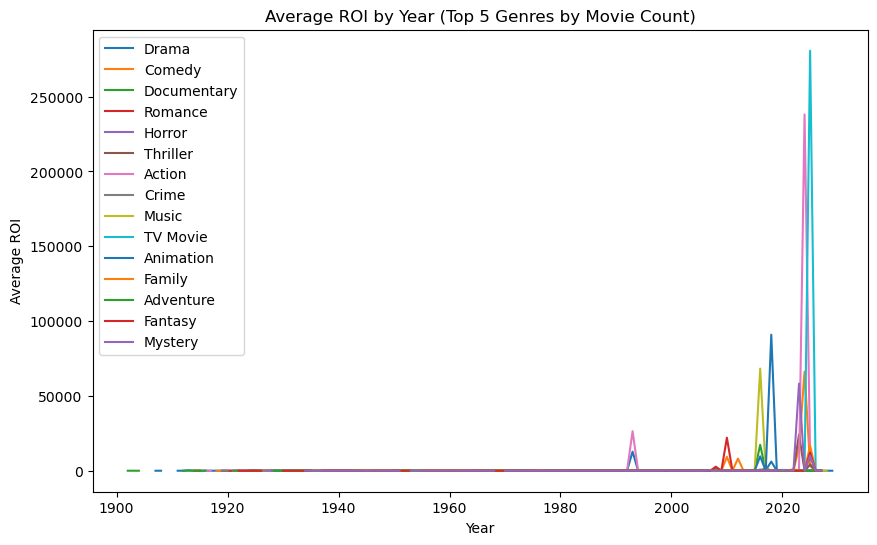

In [40]:
# I am picking  the  top 15 genres by total movie count across all years
top_genres = (
    avg_roi_by_genre_year.groupby("genre")["movie_count"].sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

plt.figure(figsize=(10,6))
for g in top_genres:
    tmp = avg_roi_by_genre_year[avg_roi_by_genre_year["genre"] == g].sort_values("year")
    plt.plot(tmp["year"], tmp["avg_roi"], label=g)

plt.title("Average ROI by Year (Top 5 Genres by Movie Count)")
plt.xlabel("Year")
plt.ylabel("Average ROI")
plt.legend()
plt.show()

## <span style="color:blue">Q3 — Profitability Threshold Filter</span>

Filtering movies where ROI > 2 (meaning the movie made more than 200% return on its budget).

In [42]:
tracemalloc.start()
start = time.perf_counter()

high_roi_movies = df[df["roi"] > 2].copy()


high_roi_movies = high_roi_movies.sort_values("roi", ascending=False)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

from IPython.display import display
display(high_roi_movies[["id", "title", "year", "revenue", "budget", "roi"]].head(20))

print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")

,id,title,year,revenue,budget,roi
499985,1300939,Verguizas Cabronas,2024,100000000,1,1.000000e+08
459654,1175807,Honk,2023,100000000,5,2.000000e+07
482845,1248416,Ginger Person,2024,10000000,1,9.999999e+06
547552,1468122,The NeedyMonster,2025,800000000,150,5.333332e+06
556306,1500094,Starters: Rare Candy,2018,20000000,4,4.999999e+06
125554,270650,Oy Vey! My Son Is Gay!,2010,6000007,2,3.000002e+06
66572,114903,Between Us,2012,2755584,1,2.755583e+06
185694,391698,The Beatles: Eight Days a Week - The Touring Y...,2016,12283800,5,2.456759e+06
41097,65299,The Judas Project,1993,2850135,2,1.425066e+06
556301,1500071,Starters - Typomaniac,2016,1000000,2,4.999990e+05


Execution Time: 0.0326 sec
Peak Memory: 9.72 MB


## <span style="color:blue">Q4: Revenue vs. Budget Correlation (by Decade)</span>

In [44]:
tracemalloc.start()
start = time.perf_counter()

# Ensuring that year exists
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

# Creating the  decade column (e.g., 1994 -> 1990)
df["decade"] = (df["year"] // 10) * 10

# I am keeping the  valid financial rows for correlation
df_corr = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()

corr_by_decade = (
    df_corr
        .groupby("decade")[["revenue", "budget"]]
        .corr()
        .iloc[::2, -1]   # selects revenue-budget correlation
        .reset_index(name="revenue_budget_corr")
        .sort_values("decade")
)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

from IPython.display import display
display(corr_by_decade)

print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")

,decade,level_1,revenue_budget_corr
0,1910,revenue,0.160273
1,1920,revenue,0.235385
2,1930,revenue,0.295073
3,1940,revenue,0.097854
4,1950,revenue,0.515112
5,1960,revenue,0.292447
6,1970,revenue,0.343887
7,1980,revenue,0.366689
8,1990,revenue,0.576564
9,2000,revenue,0.734652


Execution Time: 0.1169 sec
Peak Memory: 43.44 MB


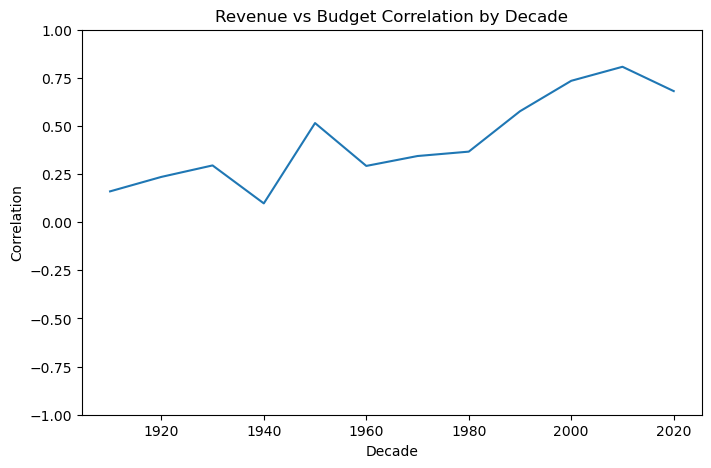

In [46]:
plt.figure(figsize=(8,5))
plt.plot(corr_by_decade["decade"], corr_by_decade["revenue_budget_corr"])
plt.title("Revenue vs Budget Correlation by Decade")
plt.xlabel("Decade")
plt.ylabel("Correlation")
plt.ylim(-1, 1)
plt.show()

## <span style="color:blue">Q5: Top 10 Most Profitable Movies per Year</span>

In [48]:
tracemalloc.start()
start = time.perf_counter()

# making sure that  year exists
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

# ensuring ROI exists 
if "roi" not in df.columns:
    raise ValueError("ROI column not found. Run Q1 (ROI per Movie) first.")

# Keeping only valid ROI rows
df_profit = df[df["roi"].notna()].copy()

# Sorting and selecting Top 10 per year by ROI
top10_profitable_per_year = (
    df_profit
        .sort_values(["year", "roi"], ascending=[True, False])
        .groupby("year")
        .head(10)
        [["year", "id", "title", "revenue", "budget", "roi"]]
)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

from IPython.display import display
display(top10_profitable_per_year.head(30))  # shows a few years worth

print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")


,year,id,title,revenue,budget,roi
608,1902,775,A Trip to the Moon,0,5985,-1.000000
3112,1903,5698,The Great Train Robbery,0,150,-1.000000
1905,1904,2963,The Impossible Voyage,0,10000,-1.000000
57962,1905,94643,Rescued by Rover,0,37,-1.000000
65930,1907,113260,Ben Hur,0,500,-1.000000
73692,1908,132394,The Adventures of Dollie,0,1000,-1.000000
461054,1911,1180455,"Water, Klimaat en Film",1,500,-0.998000
205722,1911,434136,Infidelity,0,2231,-1.000000
390487,1911,943338,The Fatal Wedding,0,800,-1.000000
404205,1911,988601,"Captain Midnight, the Bush King",0,987,-1.000000


Execution Time: 0.2179 sec
Peak Memory: 134.10 MB


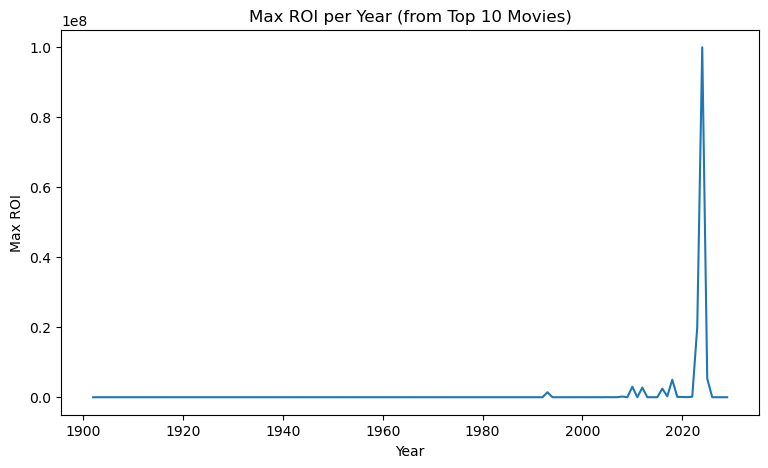

In [50]:
yearly_max_roi = (
    top10_profitable_per_year.groupby("year")["roi"].max().dropna()
)

plt.figure(figsize=(9,5))
plt.plot(yearly_max_roi.index, yearly_max_roi.values)
plt.title("Max ROI per Year (from Top 10 Movies)")
plt.xlabel("Year")
plt.ylabel("Max ROI")
plt.show()

## <span style="color:blue">Q6. Budget Distribution Statistics</span>

In [52]:
tracemalloc.start()
start = time.perf_counter()


# making budget numeric
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")

# I am only keeping the valid budgets (> 0)
df_budget = df[df["budget"] > 0].copy()

budget_stats = pd.Series({
    "count": df_budget["budget"].count(),
    "mean": df_budget["budget"].mean(),
    "std_dev": df_budget["budget"].std(),
    "variance": df_budget["budget"].var(),
    "min": df_budget["budget"].min(),
    "max": df_budget["budget"].max()
})

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

from IPython.display import display
display(budget_stats)

print(f"Execution Time: {end-start:.4f} sec")
print(f"Peak Memory: {peak/1e6:.2f} MB")

count       5.648600e+04
mean        5.593676e+06
std_dev     2.010620e+07
variance    4.042594e+14
min         1.000000e+00
max         5.839000e+08
dtype: float64

Execution Time: 0.1485 sec
Peak Memory: 131.74 MB
